# Анализ временного ряда космических запусков
## Задача 1: Разведочный анализ данных (EDA)

**Цель работы:** подготовить набор данных о космических запусках, провести его первичный анализ и визуализацию для последующего прогнозирования.

**План:**
1. Загрузка и очистка данных
2. Формирование временного ряда (ежемесячное количество запусков)
3. Базовые статистики и проверка пропусков
4. Визуализация ряда: тренд, сезонность, шум
5. Анализ стационарности (тест Дики-Фуллера)
6. Декомпозиция и коррелограммы
7. Анализ вклада основных компаний
8. Сохранение подготовленных данных

In [2]:
# 1. Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей
sns.set_style('whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

# Создание директории для результатов
import os
os.makedirs('results', exist_ok=True)

print("Библиотеки загружены")

Библиотеки загружены


## 2. Загрузка и предварительная обработка данных

In [3]:
# Загрузка данных из исходного репозитория
url = 'https://raw.githubusercontent.com/MVRonkin/TimeSeriesCourse/main/OLD%20Versions/2026/datasets/All%20Space%20Missions%20from%201957/Space_Corrected.csv'
df = pd.read_csv(url)

# Приведение названий столбцов к удобному виду
df.columns = df.columns.str.strip()
df = df.rename(columns={
    'Unnamed: 0': 'id',
    'Company Name': 'company',
    'Status Rocket': 'rocket_status',
    'Rocket': 'cost_millions',
    'Status Mission': 'mission_status'
})

# Функция парсинга даты (с учётом UTC)
def parse_date(date_str):
    date_str = str(date_str).strip()
    if ' UTC' in date_str:
        date_str = date_str.replace(' UTC', '')
        return pd.to_datetime(date_str, format='%a %b %d, %Y %H:%M')
    else:
        return pd.to_datetime(date_str, format='%a %b %d, %Y')

df['Datum'] = df['Datum'].apply(parse_date)
df = df.dropna(subset=['Datum'])
df['Datum'] = pd.to_datetime(df['Datum'], utc=True).dt.tz_convert(None)

print(f'Размер данных после очистки: {df.shape}')
print('Типы данных:')
print(df.dtypes)
print('\nКоличество пропусков:')
print(df.isna().sum())
df.head(3)

Размер данных после очистки: (4324, 9)
Типы данных:
Unnamed: 0.1               int64
id                         int64
company                      str
Location                     str
Datum             datetime64[us]
Detail                       str
rocket_status                str
cost_millions                str
mission_status               str
dtype: object

Количество пропусков:
Unnamed: 0.1         0
id                   0
company              0
Location             0
Datum                0
Detail               0
rocket_status        0
cost_millions     3360
mission_status       0
dtype: int64


,Unnamed: 0.1,id,company,Location,Datum,Detail,rocket_status,cost_millions,mission_status
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA",2020-08-07 05:12:00,Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...",2020-08-06 04:01:00,Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA",2020-08-04 23:57:00,Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success


## 3. Формирование ежемесячного временного ряда

In [4]:
# Устанавливаем дату как индекс и сортируем
df.set_index('Datum', inplace=True)
df.sort_index(inplace=True)

# Агрегируем по месяцам: количество запусков
monthly_launches = df.resample('MS').size()
monthly_launches.name = 'launches'

# Проверка на пропущенные месяцы
full_range = pd.date_range(start=monthly_launches.index.min(),
                           end=monthly_launches.index.max(),
                           freq='MS')
missing = full_range.difference(monthly_launches.index)
if len(missing) > 0:
    print(f'Обнаружено пропущенных месяцев: {len(missing)}. Заполняем нулями.')
    monthly_launches = monthly_launches.reindex(full_range, fill_value=0)
    monthly_launches.index.freq = 'MS'
else:
    print('Индекс непрерывен.')

print(f'Диапазон дат: {monthly_launches.index.min().date()} — {monthly_launches.index.max().date()}')
print(f'Всего точек: {len(monthly_launches)}')
monthly_launches.head(10)

Индекс непрерывен.
Диапазон дат: 1957-10-01 — 2020-08-01
Всего точек: 755


Datum
1957-10-01    1
1957-11-01    1
1957-12-01    1
1958-01-01    0
1958-02-01    2
1958-03-01    3
1958-04-01    2
1958-05-01    2
1958-06-01    1
1958-07-01    2
Freq: MS, Name: launches, dtype: int64

## 4. Базовый статистический анализ ряда

Основные статистики ряда:
count    755.000000
mean       5.727152
std        3.109367
min        0.000000
25%        4.000000
50%        5.000000
75%        8.000000
max       18.000000
Name: launches, dtype: float64

Количество месяцев с нулевым числом запусков: 8
Монотонность индекса: True
Дубликаты индекса: False


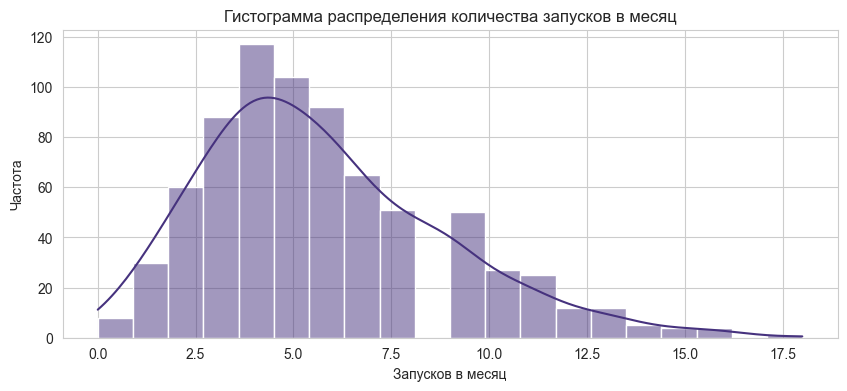

In [5]:
print('Основные статистики ряда:')
print(monthly_launches.describe())
print(f'\nКоличество месяцев с нулевым числом запусков: {(monthly_launches == 0).sum()}')
print(f'Монотонность индекса: {monthly_launches.index.is_monotonic_increasing}')
print(f'Дубликаты индекса: {monthly_launches.index.has_duplicates}')

# Дополнительно: распределение запусков
plt.figure(figsize=(10,4))
sns.histplot(monthly_launches, bins=20, kde=True)
plt.title('Гистограмма распределения количества запусков в месяц')
plt.xlabel('Запусков в месяц')
plt.ylabel('Частота')
plt.savefig('results/hist_launches.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Визуализация временного ряда

Интерактивный график сохранён в results/monthly_launches_interactive.html


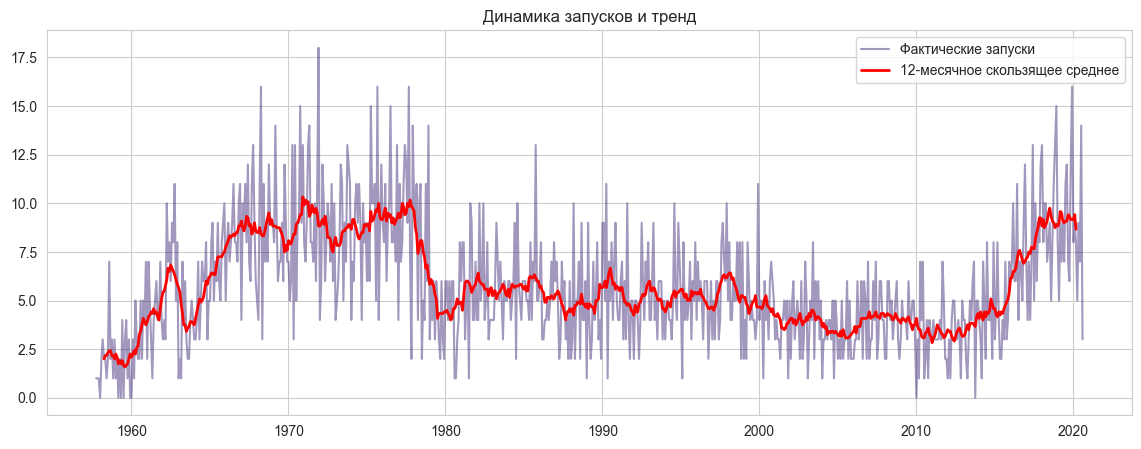

In [7]:
# Интерактивный график с plotly
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=monthly_launches.index,
    y=monthly_launches.values,
    mode='lines+markers',
    name='Количество запусков',
    line=dict(width=1),
    marker=dict(size=3)
))
fig.update_layout(
    title='Ежемесячное количество космических запусков (1957–2020)',
    xaxis_title='Дата',
    yaxis_title='Запусков в месяц',
    height=500
)
fig.write_html('results/monthly_launches_interactive.html')
print("Интерактивный график сохранён в results/monthly_launches_interactive.html")
# fig.show()  # Закомментировано для избежания ошибки с nbformat

# Статический график со сглаживанием
rolling = monthly_launches.rolling(window=12, center=True).mean()
plt.figure(figsize=(14,5))
plt.plot(monthly_launches.index, monthly_launches, alpha=0.5, label='Фактические запуски')
plt.plot(rolling.index, rolling, color='red', linewidth=2, label='12-месячное скользящее среднее')
plt.title('Динамика запусков и тренд')
plt.legend()
plt.grid(True)
plt.savefig('results/trend_smoothed.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Анализ сезонности и тренда

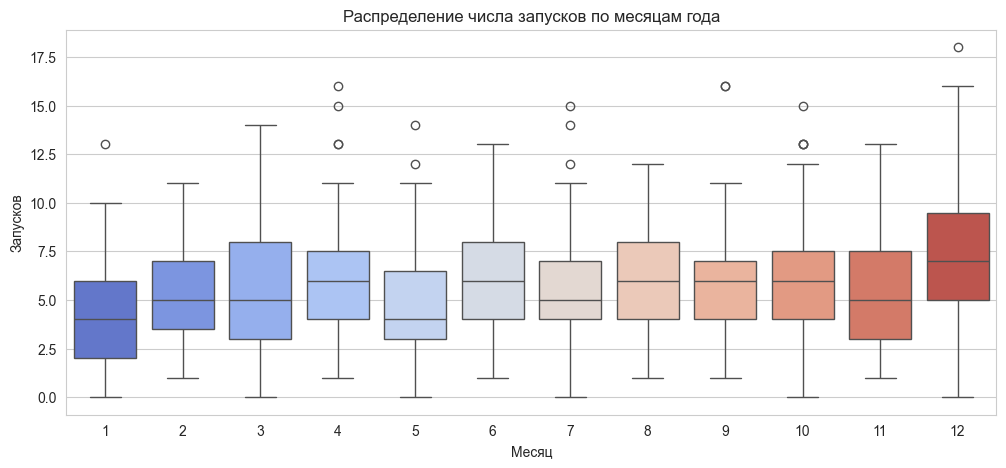

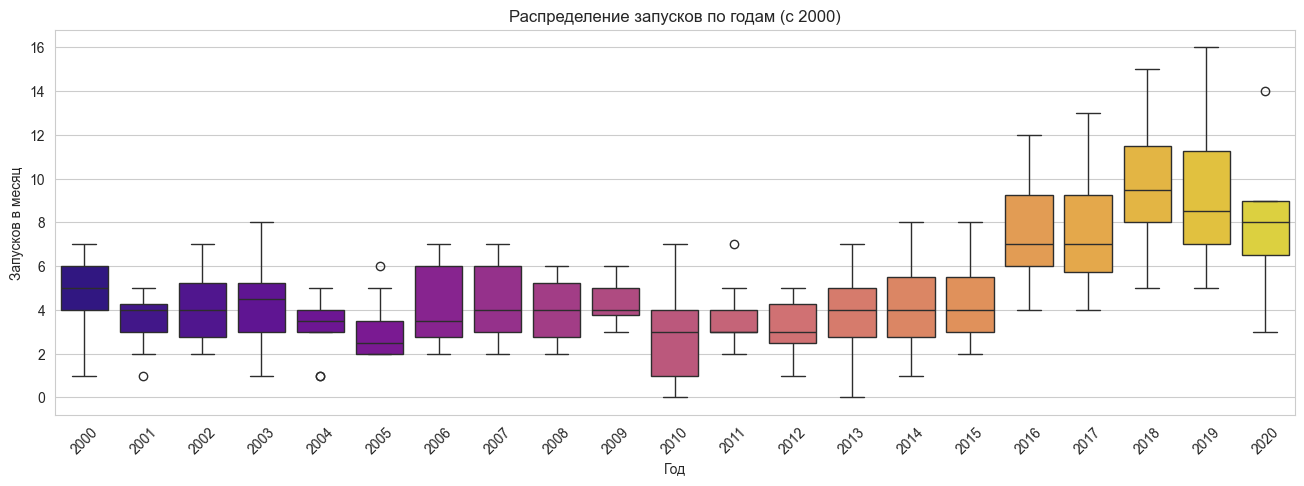

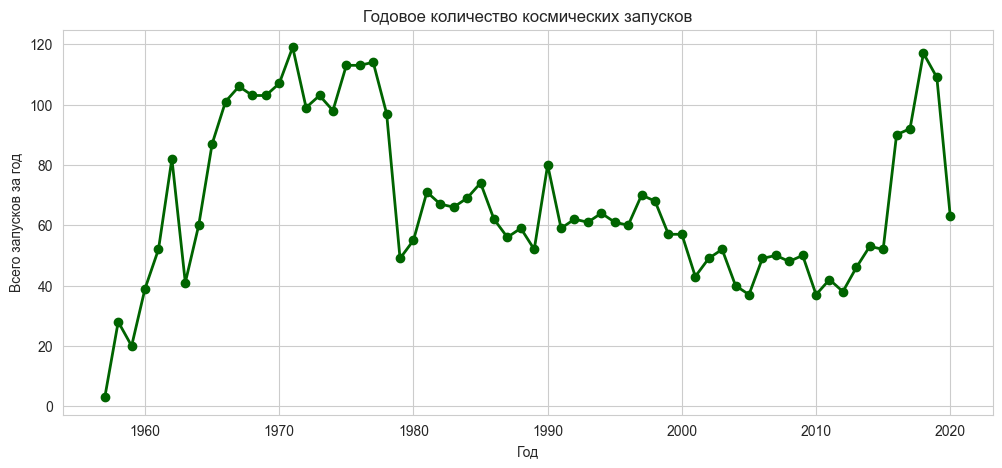

In [8]:
# Boxplot по месяцам (сезонность)
df_box = monthly_launches.to_frame()
df_box['month'] = df_box.index.month

plt.figure(figsize=(12,5))
sns.boxplot(x='month', y='launches', data=df_box, palette='coolwarm')
plt.title('Распределение числа запусков по месяцам года')
plt.xlabel('Месяц')
plt.ylabel('Запусков')
plt.savefig('results/seasonal_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

# Boxplot по годам (тренд) — с 2000 года
df_box['year'] = df_box.index.year
plt.figure(figsize=(16,5))
sns.boxplot(x='year', y='launches', data=df_box[df_box['year'] >= 2000], palette='plasma')
plt.xticks(rotation=45)
plt.title('Распределение запусков по годам (с 2000)')
plt.xlabel('Год')
plt.ylabel('Запусков в месяц')
plt.savefig('results/yearly_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

# Годовое агрегирование (суммарные запуски за год)
annual = monthly_launches.resample('YS').sum()
plt.figure(figsize=(12,5))
plt.plot(annual.index, annual.values, marker='o', linestyle='-', linewidth=2, color='darkgreen')
plt.title('Годовое количество космических запусков')
plt.xlabel('Год')
plt.ylabel('Всего запусков за год')
plt.grid(True)
plt.savefig('results/annual_launches.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Декомпозиция временного ряда (аддитивная модель)

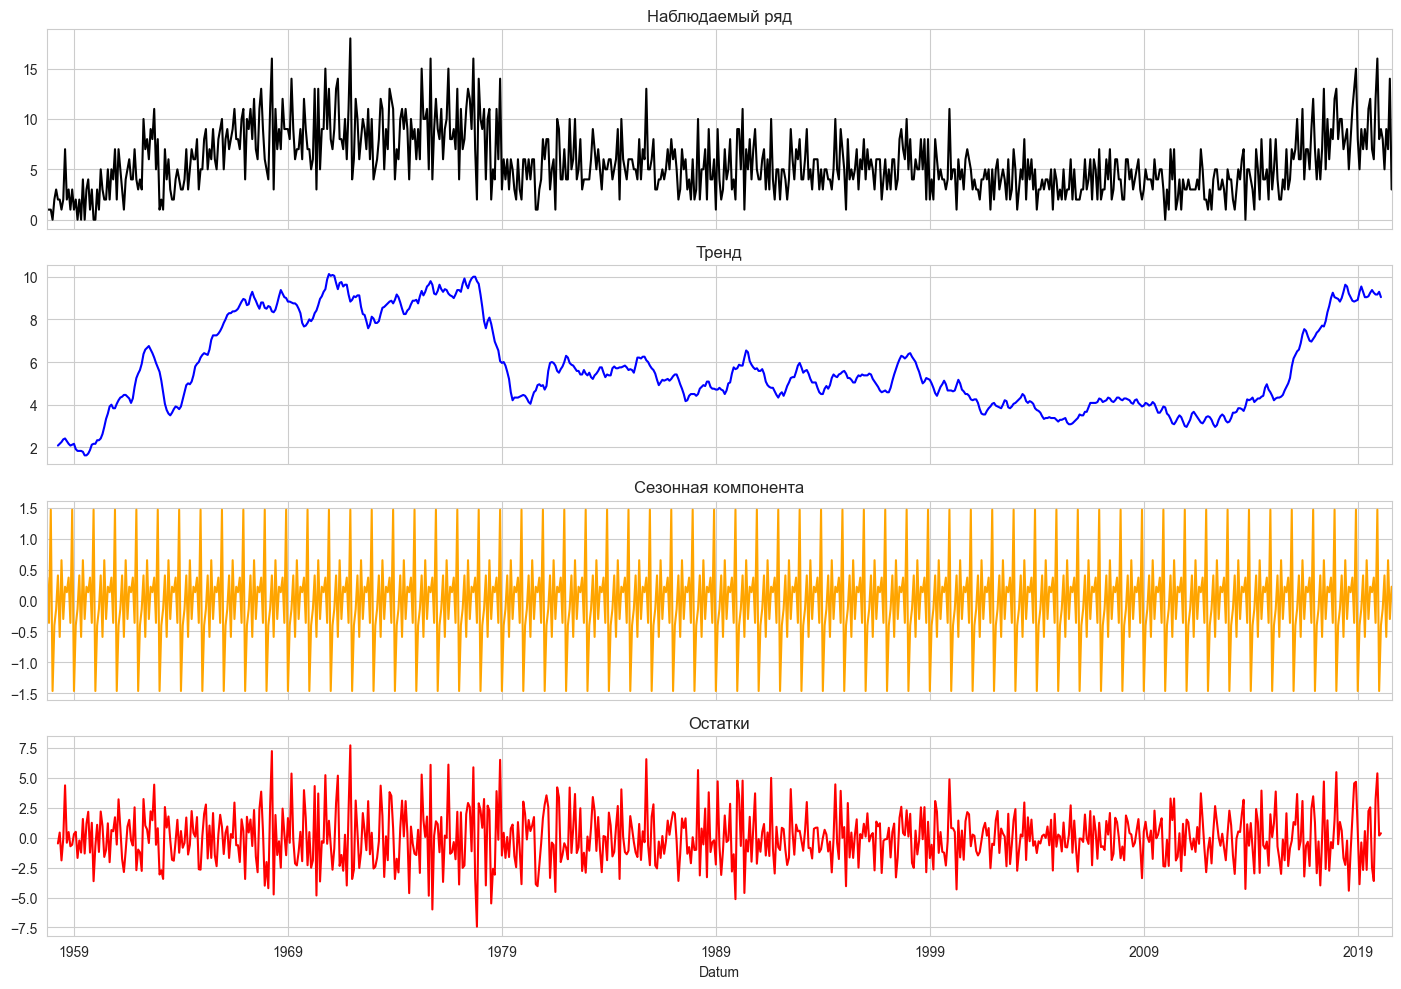

In [9]:
decomp = seasonal_decompose(monthly_launches, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomp.observed.plot(ax=axes[0], title='Наблюдаемый ряд', color='black')
decomp.trend.plot(ax=axes[1], title='Тренд', color='blue')
decomp.seasonal.plot(ax=axes[2], title='Сезонная компонента', color='orange')
decomp.resid.plot(ax=axes[3], title='Остатки', color='red')
plt.tight_layout()
plt.savefig('results/decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Коррелограммы (ACF и PACF)

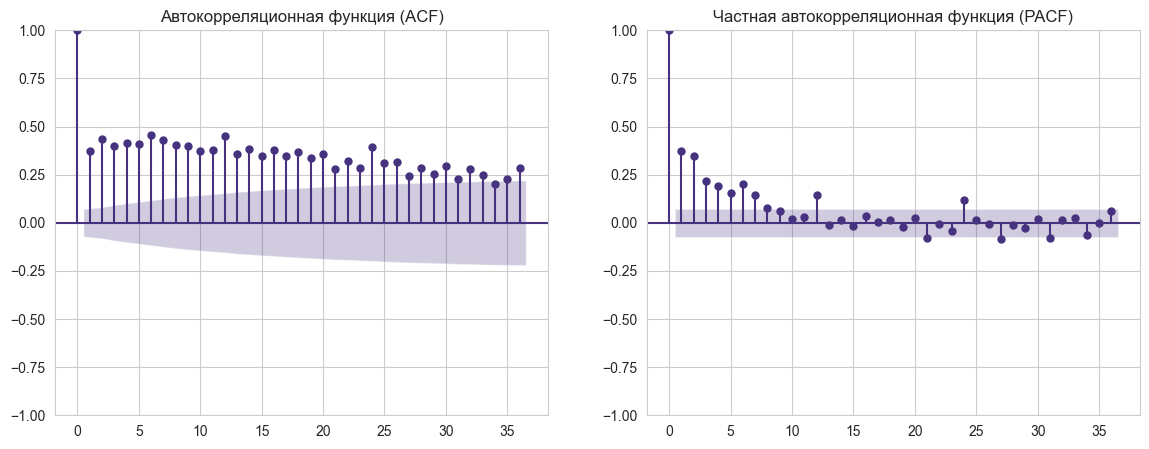

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
plot_acf(monthly_launches, lags=36, ax=axes[0], title='Автокорреляционная функция (ACF)')
plot_pacf(monthly_launches, lags=36, ax=axes[1], method='ywm', title='Частная автокорреляционная функция (PACF)')
plt.savefig('results/acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Тест на стационарность (Дики-Фуллер)

Результаты теста Дики-Фуллера:
p-value: 0.14603
Ряд нестационарен. Требуется дифференцирование или преобразование.


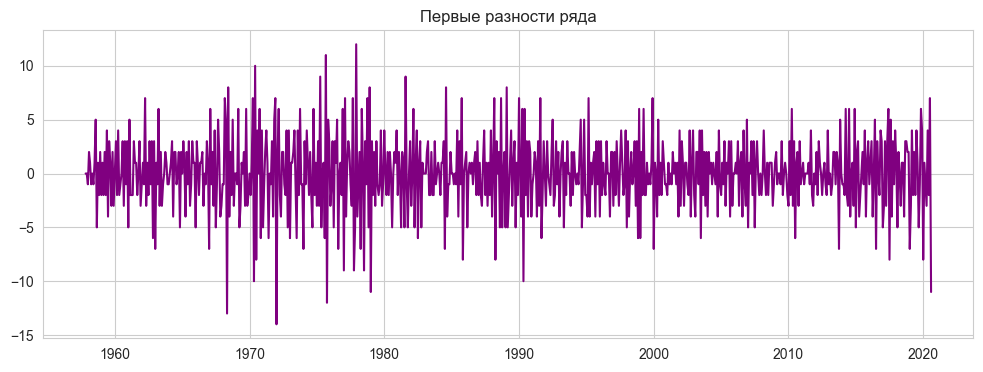

In [11]:
result = adfuller(monthly_launches)
print('Результаты теста Дики-Фуллера:')
print(f'p-value: {result[1]:.5f}')
if result[1] <= 0.05:
    print('Ряд стационарен (отвергаем H0).')
else:
    print('Ряд нестационарен. Требуется дифференцирование или преобразование.')

# Для наглядности: посмотрим на ряд первых разностей
monthly_diff = monthly_launches.diff().dropna()
plt.figure(figsize=(12,4))
plt.plot(monthly_diff, color='purple')
plt.title('Первые разности ряда')
plt.grid(True)
plt.savefig('results/diff_series.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Анализ вклада ведущих компаний

Топ-5 компаний: ['RVSN USSR', 'Arianespace', 'General Dynamics', 'CASC', 'NASA']


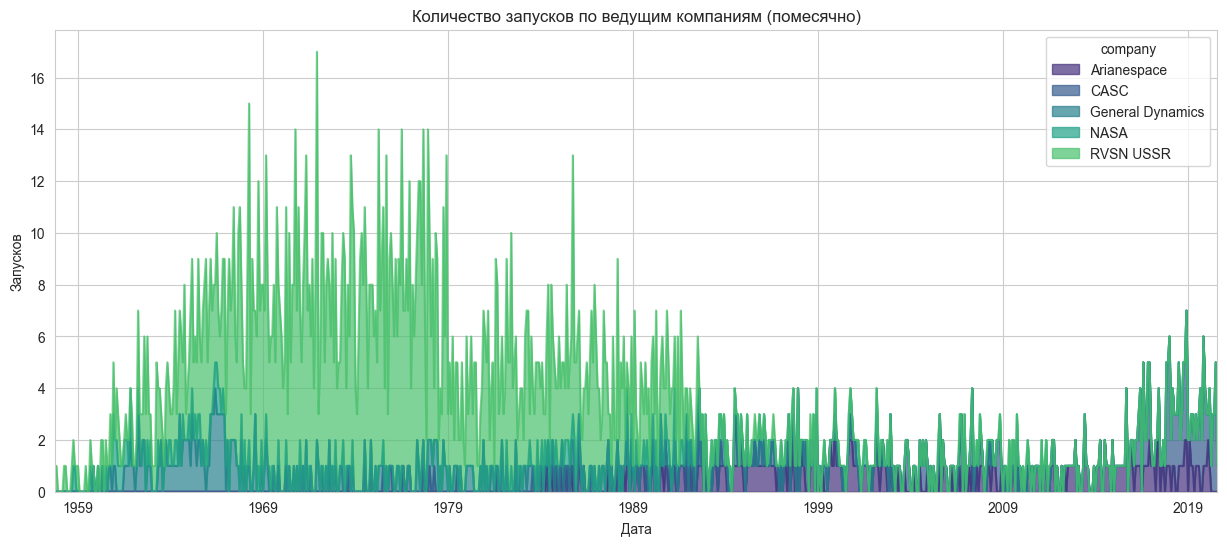

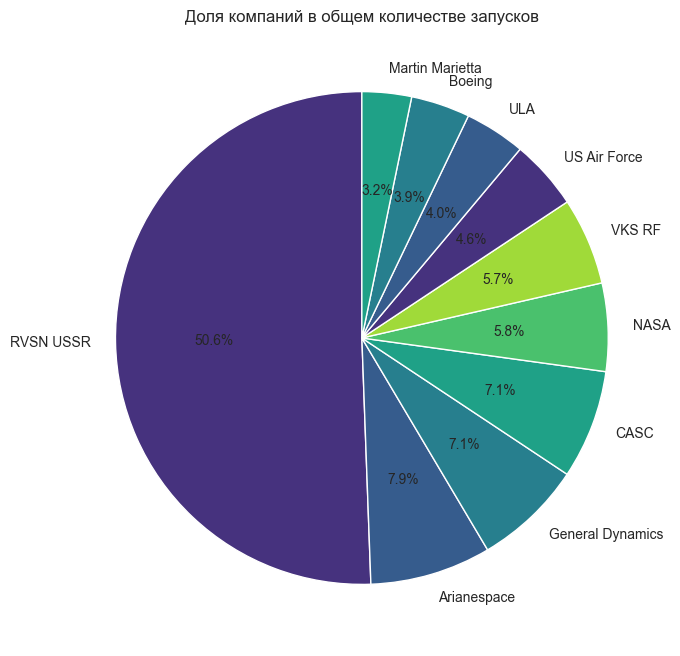

In [12]:
# Определим топ-5 компаний по общему числу запусков
top_companies = df['company'].value_counts().head(5).index.tolist()
print('Топ-5 компаний:', top_companies)

# Отфильтруем данные по этим компаниям
df_top = df[df['company'].isin(top_companies)]

# Построим помесячную динамику запусков по компаниям (area chart)
company_monthly = df_top.groupby('company').resample('MS').size().unstack(level=0, fill_value=0)

company_monthly.plot.area(figsize=(15,6), alpha=0.7, stacked=True)
plt.title('Количество запусков по ведущим компаниям (помесячно)')
plt.ylabel('Запусков')
plt.xlabel('Дата')
plt.savefig('results/companies_area.png', dpi=150, bbox_inches='tight')
plt.show()

# Доля каждой компании в общем числе запусков
total_by_company = df['company'].value_counts()
plt.figure(figsize=(8,8))
total_by_company.head(10).plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Доля компаний в общем количестве запусков')
plt.ylabel('')
plt.savefig('results/companies_pie.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Сохранение подготовленного ряда для дальнейшего моделирования

In [13]:
monthly_launches.to_csv('results/monthly_launches.csv', header=True)
print('Ряд сохранён в results/monthly_launches.csv')

# Дополнительно сохраним агрегированные данные по компаниям
company_monthly.to_csv('results/company_monthly_launches.csv')
print('Данные по компаниям сохранены в results/company_monthly_launches.csv')

print('\nEDA завершён. Все графики и данные сохранены в папку results/')

Ряд сохранён в results/monthly_launches.csv
Данные по компаниям сохранены в results/company_monthly_launches.csv

EDA завершён. Все графики и данные сохранены в папку results/
